In [1]:
from google.colab import drive
drive.mount('/content/ggdrive')

Mounted at /content/ggdrive


In [2]:
# Accessed and imported libraries to load and process CSV files.
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
df = pd.read_csv('/content/ggdrive/MyDrive/Data Analyst/Module 3: Python/Project.Python/sales_data.csv')
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)
df.head()

,Date,Store ID,Product ID,Category,Region,Inventory Level,Units Sold,Units Ordered,Price,Discount,Weather Condition,Promotion,Competitor Pricing,Seasonality,Epidemic,Demand
0,2022-01-01,S001,P0001,Electronics,North,195,102,252,72.72,5,Snowy,0,85.73,Winter,0,115
1,2022-01-01,S001,P0002,Clothing,North,117,117,249,80.16,15,Snowy,1,92.02,Winter,0,229
2,2022-01-01,S001,P0003,Clothing,North,247,114,612,62.94,10,Snowy,1,60.08,Winter,0,157
3,2022-01-01,S001,P0004,Electronics,North,139,45,102,87.63,10,Snowy,0,85.19,Winter,0,52
4,2022-01-01,S001,P0005,Groceries,North,152,65,271,54.41,0,Snowy,0,51.63,Winter,0,59


In [3]:
# Chuyển Date thành loại Datetime
df['Date'] = pd.to_datetime(df['Date'])
df.dtypes

,0
Date,datetime64[ns]
Store ID,object
Product ID,object
Category,object
Region,object
Inventory Level,int64
Units Sold,int64
Units Ordered,int64
Price,float64
Discount,int64


In [4]:
df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month
df['Month_Year'] = df['Date'].dt.to_period('M')
df['Week'] = df['Date'].dt.isocalendar().week
df.head()

,Date,Store ID,Product ID,Category,Region,Inventory Level,Units Sold,Units Ordered,Price,Discount,Weather Condition,Promotion,Competitor Pricing,Seasonality,Epidemic,Demand,Year,Month,Month_Year,Week
0,2022-01-01,S001,P0001,Electronics,North,195,102,252,72.72,5,Snowy,0,85.73,Winter,0,115,2022,1,2022-01,52
1,2022-01-01,S001,P0002,Clothing,North,117,117,249,80.16,15,Snowy,1,92.02,Winter,0,229,2022,1,2022-01,52
2,2022-01-01,S001,P0003,Clothing,North,247,114,612,62.94,10,Snowy,1,60.08,Winter,0,157,2022,1,2022-01,52
3,2022-01-01,S001,P0004,Electronics,North,139,45,102,87.63,10,Snowy,0,85.19,Winter,0,52,2022,1,2022-01,52
4,2022-01-01,S001,P0005,Groceries,North,152,65,271,54.41,0,Snowy,0,51.63,Winter,0,59,2022,1,2022-01,52


In [5]:
# Check the data time frame
latest_date = df['Date'].max()
latest_month = latest_date.month
latest_year = latest_date.year
print("Latest day:", latest_date, latest_month)

# Select data from the latest three-month period
last_three_months = df[df['Date'] >= '2023-11-01'].reset_index(drop=True)
last_three_months.head()

# Select year-over-year comparable data
same_month_last_year = df[(df['Month'] == latest_month) & (df['Year'] == latest_year - 1)].reset_index(drop=True)
same_month_last_year.head()

Latest day: 2024-01-30 00:00:00 1


,Date,Store ID,Product ID,Category,Region,Inventory Level,Units Sold,Units Ordered,Price,Discount,Weather Condition,Promotion,Competitor Pricing,Seasonality,Epidemic,Demand,Year,Month,Month_Year,Week
0,2023-01-01,S001,P0001,Electronics,North,288,76,278,73.60,5,Cloudy,0,86.55,Winter,0,119,2023,1,2023-01,52
1,2023-01-01,S001,P0002,Clothing,North,301,83,0,62.06,5,Cloudy,0,74.84,Winter,0,95,2023,1,2023-01,52
2,2023-01-01,S001,P0003,Clothing,North,349,54,0,46.58,5,Cloudy,0,43.14,Winter,0,49,2023,1,2023-01,52
3,2023-01-01,S001,P0004,Electronics,North,190,91,221,112.97,0,Cloudy,0,121.06,Winter,0,109,2023,1,2023-01,52
4,2023-01-01,S001,P0005,Groceries,North,365,194,0,77.10,0,Cloudy,0,67.29,Winter,0,169,2023,1,2023-01,52


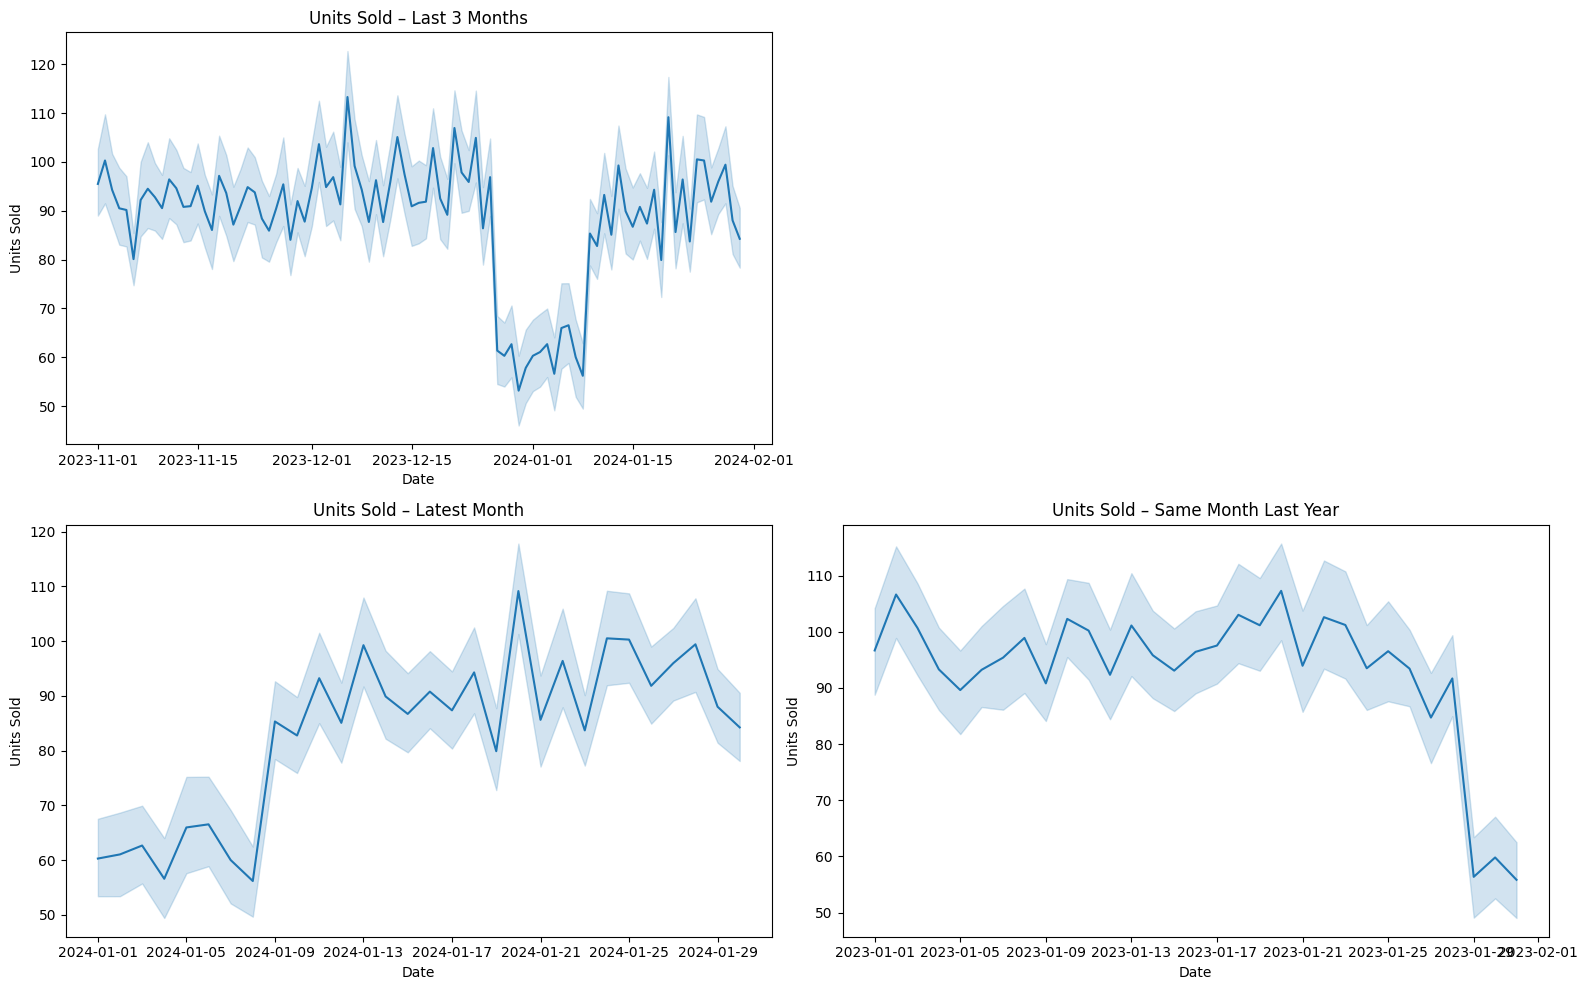

In [6]:
# Line chart illustrating the number of units sold over the past three months
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

sns.lineplot(ax=axes[0, 0], data=last_three_months, x='Date', y='Units Sold')
axes[0, 0].set_title("Units Sold – Last 3 Months")

axes[0, 1].axis('off')

current_month = df[(df['Year'] == latest_year) & (df['Month'] == latest_month)].reset_index(drop=True)
sns.lineplot(ax=axes[1, 0], data=current_month, x='Date', y='Units Sold')
axes[1, 0].set_title("Units Sold – Latest Month")

sns.lineplot(ax=axes[1, 1], data=same_month_last_year, x='Date', y='Units Sold')
axes[1, 1].set_title("Units Sold – Same Month Last Year")

plt.tight_layout()
plt.show()

# There was a clear difference in business trends: while units sold in Jan 2024 started low and increased later,
# Jan 2023 showed the opposite, remaining high at first but decreasing toward the end of the month

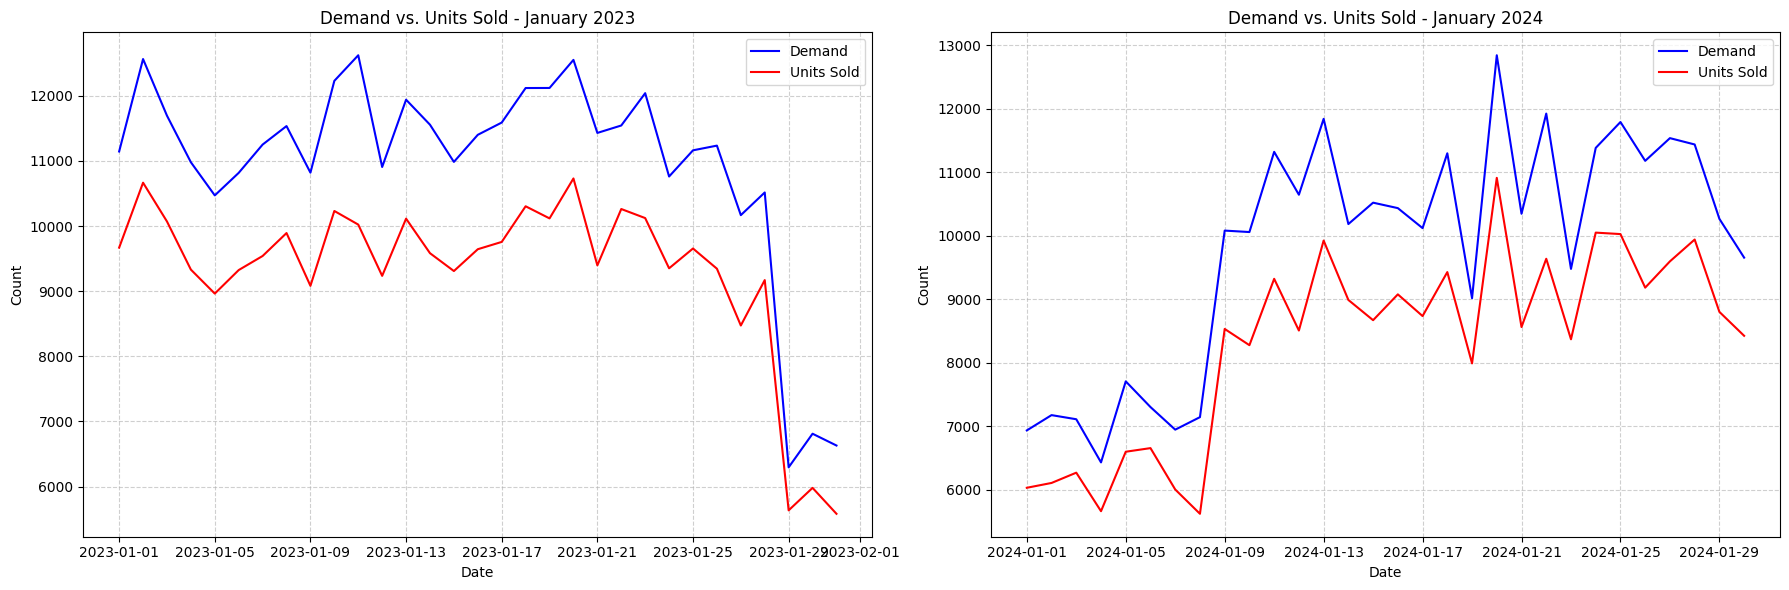

In [7]:
df_jan_2023 = df[(df['Year'] == 2023) & (df['Month'] == 1)]
df_jan_2024 = df[(df['Year'] == 2024) & (df['Month'] == 1)]

daily_summary_2023 = df_jan_2023.groupby('Date')[['Units Sold', 'Demand']].sum().reset_index()
daily_summary_2024 = df_jan_2024.groupby('Date')[['Units Sold', 'Demand']].sum().reset_index()

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Chart comparing actual sales and forecast – January 2023
sns.lineplot(ax=axes[0], data=daily_summary_2023, x='Date', y='Demand', label='Demand', color='blue')
sns.lineplot(ax=axes[0], data=daily_summary_2023, x='Date', y='Units Sold', label='Units Sold', color='red')
axes[0].set_title('Demand vs. Units Sold - January 2023')
axes[0].set_xlabel('Date')
axes[0].set_ylabel('Count')
axes[0].legend()
axes[0].grid(True, linestyle='--', alpha=0.6)

# Chart comparing actual sales and forecast – January 2024
sns.lineplot(ax=axes[1], data=daily_summary_2024, x='Date', y='Demand', label='Demand', color='blue')
sns.lineplot(ax=axes[1], data=daily_summary_2024, x='Date', y='Units Sold', label='Units Sold', color='red')
axes[1].set_title('Demand vs. Units Sold - January 2024')
axes[1].set_xlabel('Date')
axes[1].set_ylabel('Count')
axes[1].legend()
axes[1].grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

# A comparison between demand forecasts and actual sales was performed to check whether this situation was anticipated.
# The analysis showed that the outcome was within expectations, consistently showing an over-forecasting status where forecasts were higher than actual demand.

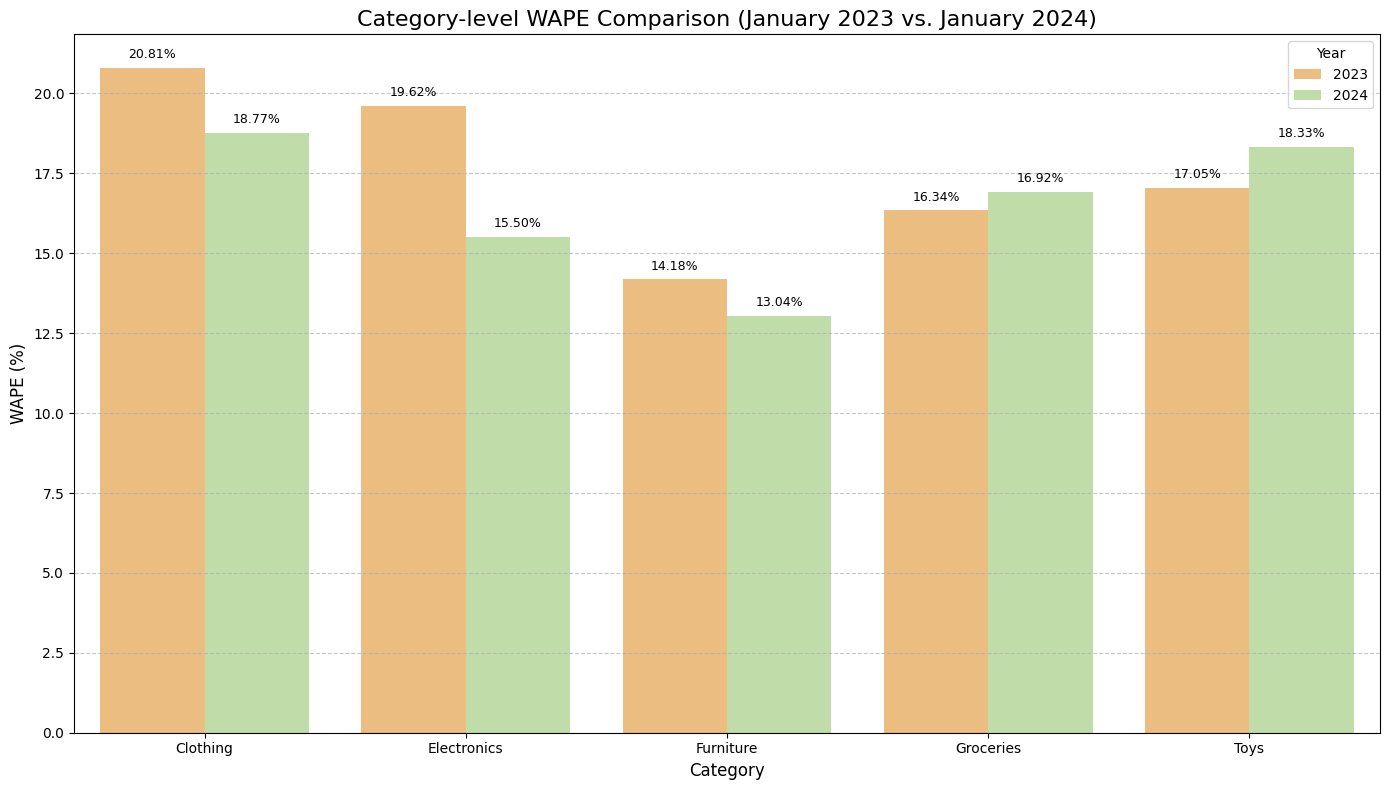

In [22]:
same_month_last_year_sorted = same_month_last_year[same_month_last_year['Inventory Level'] != 0]

# Most recent data available: January 2024
current_month_sorted = current_month[current_month['Inventory Level'] != 0]

total_us_d_2 = (same_month_last_year_sorted.groupby(['Store ID', 'Category', 'Product ID', 'Month_Year', 'Week'])[['Units Sold', 'Demand', 'Units Ordered']].sum().reset_index())
total_us_d_2['Error 1/2023'] = total_us_d_2['Units Sold'] - total_us_d_2['Demand']
total_us_d_2['Absolute Error 1/2023'] = abs(total_us_d_2['Error 1/2023'])

total_us_d_3 = (current_month_sorted.groupby(['Store ID', 'Category', 'Product ID', 'Month_Year', 'Week'])[['Units Sold', 'Demand', 'Units Ordered']].sum().reset_index())
total_us_d_3['Error 1/2024'] = total_us_d_3['Units Sold'] - total_us_d_3['Demand']
total_us_d_3['Absolute Error 1/2024'] = abs(total_us_d_3['Error 1/2024'])

wape_category_all_stores_2023 = pd.DataFrame()
wape_category_all_stores_2024 = pd.DataFrame()

# MAPE of each Category by store - January 2023
category_2_all = (total_us_d_2.groupby(['Category', 'Week'])[['Units Ordered', 'Units Sold', 'Demand']].sum().reset_index())
category_2_all['Error 1/2023'] = category_2_all['Units Sold'] - category_2_all['Demand']
category_2_all['Absolute Error 1/2023'] = abs(category_2_all['Error 1/2023'])
wape_category_all_stores_2023 = (category_2_all.groupby('Category')[['Units Ordered', 'Units Sold', 'Demand', 'Error 1/2023', 'Absolute Error 1/2023']].sum().reset_index())
wape_category_all_stores_2023['WAPE 1/2023'] = round(wape_category_all_stores_2023['Absolute Error 1/2023'] / wape_category_all_stores_2023['Units Sold'] * 100, 2)

# MAPE of each Category by store - January 2024
category_3_all = (total_us_d_3.groupby(['Category', 'Week'])[['Units Ordered', 'Units Sold', 'Demand']].sum().reset_index())
category_3_all['Error 1/2024'] = category_3_all['Units Sold'] - category_3_all['Demand']
category_3_all['Absolute Error 1/2024'] = abs(category_3_all['Error 1/2024'])
wape_category_all_stores_2024 = (category_3_all.groupby('Category')[['Units Ordered', 'Units Sold', 'Demand', 'Error 1/2024', 'Absolute Error 1/2024']].sum().reset_index())
wape_category_all_stores_2024['WAPE 1/2024'] = round(wape_category_all_stores_2024['Absolute Error 1/2024'] / wape_category_all_stores_2024['Units Sold'] * 100, 2)

wape_category_2p = pd.merge(wape_category_all_stores_2023, wape_category_all_stores_2024, on=['Category'], how='outer')

# Bar chart comparing WAPE by category at two periods
plot_df_category = wape_category_2p[['Category', 'WAPE 1/2023', 'WAPE 1/2024']].copy()
plot_df_category.rename(columns={'WAPE 1/2023': '2023', 'WAPE 1/2024': '2024'}, inplace=True)

plot_df_category_melted = plot_df_category.melt(id_vars=['Category'], var_name='Year', value_name='WAPE')

plt.figure(figsize=(14, 8))
sns.barplot(data=plot_df_category_melted, x='Category', y='WAPE', hue='Year', palette='Spectral')

plt.title('Category-level WAPE Comparison (January 2023 vs. January 2024)', fontsize=16)
plt.xlabel('Category', fontsize=12)
plt.ylabel('WAPE (%)', fontsize=12)
plt.legend(title='Year')
plt.grid(axis='y', linestyle='--', alpha=0.7)

for container in plt.gca().containers:
   for patch in container.patches:
       plt.annotate(f'{patch.get_height():.2f}%',
                    (patch.get_x() + patch.get_width() / 2, patch.get_height()),
                    ha='center', va='bottom', fontsize=9, color='black', xytext=(0, 5),
                    textcoords='offset points')

plt.tight_layout()
plt.show()
# Regarding forecast accuracy, the WAPE ranking across categories remained the same as in the previous period.
# However, forecast accuracy for Clothing, Electronics and Furniture improved, while the opposite was true for Groceries and Toys.

In [21]:
# FORECAST PERFORMANCE EVALUATION - LAST THREE MONTHS (PRODUCT & CATEGORY & STORE, weekly basis)
# Records with Inventory Level equal to zero were removed to avoid affecting the evaluation of demand forecast accuracy.
last_three_months_sorted = last_three_months[last_three_months['Inventory Level'] != 0]
total_us_d = last_three_months_sorted.groupby(['Store ID', 'Category', 'Product ID', 'Month_Year', 'Week'])[['Units Sold', 'Demand', 'Units Ordered']].sum().reset_index()
total_us_d['Difference'] = total_us_d['Units Sold'] - total_us_d['Demand']
total_us_d['Error'] = abs(total_us_d['Difference'])

for store in total_us_d['Store ID'].unique():
 total_us_d_store = total_us_d[total_us_d['Store ID'] == store]

 # MAPE of each Product ID by store
 wape_product = total_us_d_store.groupby(['Category', 'Product ID'])[['Units Ordered', 'Units Sold', 'Demand', 'Difference', 'Error']].sum().reset_index()
 wape_product['WAPE'] = round(wape_product['Error'] / wape_product['Units Sold'] * 100, 2)

 # MAPE of each Category by store
 category = (total_us_d_store.groupby(['Category', 'Week'])[['Units Ordered', 'Units Sold', 'Demand']].sum().reset_index())
 category['Difference'] = category['Units Sold'] - category['Demand']
 category['Error'] = abs(category['Difference'])
 wape_category = (category.groupby('Category')[['Units Ordered', 'Units Sold', 'Demand', 'Difference', 'Error']].sum().reset_index())
 wape_category['WAPE'] = round(wape_category['Error'] / wape_category['Units Sold'] * 100, 2)

 # MAPE of Store ID
 store_df = (total_us_d_store.groupby(['Store ID', 'Week'])[['Units Ordered', 'Units Sold', 'Demand']].sum().reset_index())
 store_df['Difference'] = store_df['Units Sold'] - store_df['Demand']
 store_df['Error'] = abs(store_df['Difference'])
 wape_store = (store_df.groupby('Store ID')[['Units Ordered', 'Units Sold', 'Demand', 'Difference', 'Error']].sum().reset_index())
 wape_store['WAPE'] = round(wape_store['Error'] / wape_store['Units Sold'] * 100, 2)

 print("Store:", store)
 print("WAPE per Product:")
 print(wape_product[['Category', 'Product ID', 'Units Sold', 'Demand', 'Error', 'WAPE']])
 print("WAPE per Category:")
 print(wape_category[['Category', 'Units Sold', 'Demand', 'Error', 'WAPE']])
 print(f"WAPE of Store {store}: {wape_store['WAPE'].iloc[0]}%")

 # S001: It is necessary to pay attention to the forecasts for Toys and Clothing,
 # as they were the categories with the highest sales volumes, especially Toys, where all products had higher WAPE than most others.
 # Product IDs needing attention due to high WAPE (>20%): P008 (Electronics) - 25.97%, P0017 (Toys) - 32.40%.
 # S002: Groceries and Clothing products had similar sales volumes.
 # Therefore, if demand forecasts for these products are improved, the company can improve the WAPE for these products.
 # Product IDs needing attention due to high WAPE (>20%): P006 (Clothing) - 30.17%, P0018 (Clothing) - 26.6%, P008 (Groceries) - 24.84%, P0010 (Groceries) - 24.10%.
 # S003: Groceries products had relatively stable actual sales volumes,
 # leading to a similar impact of WAPE across products.
 # However, due to the short shelf life of this category,
 # over-forecasting may result in excess inventory, higher spoilage risk, and increased operational costs.
 # Product IDs needing attention due to high WAPE (>20%): P009 (Groceries) - 29.06%, P0010 (Groceries) - 27.96%, P0019 (Groceries) - 22.69%.
 # S004: Despite having only one product, the Electronics category should still be given special attention, as this product had the highest WAPE.
 # Electronics products usually have relatively high unit value. Over-forecasting can lead to excess inventory,
 # which creates greater financial pressure for the business compared to other categories.
 # Product IDs needing attention due to high WAPE (>20%): P0012 (Electronics) - 31.35%, P005 (Clothing) - 26.95% và P0017 (Clothing) - 22.42%
 # S005: Although Clothing had one product with high WAPE, its sales volume was relatively similar to other products.
 # Therefore, this product should be managed equally with others in the forecasting process.
 # Product IDs needing attention due to high WAPE (>20%): P0018 (Clothing) - 32.79%, P008 (Groceries) - 28,53%

Store: S001
WAPE per Product:
       Category Product ID  Units Sold  Demand  Error   WAPE
0      Clothing      P0002        8801   10735   1934  21.97
1      Clothing      P0003       10793   12082   1395  12.93
2      Clothing      P0009       10643   12738   2095  19.68
3   Electronics      P0001        8009    8856    847  10.58
4   Electronics      P0004        7443    8640   1219  16.38
5   Electronics      P0008        6950    8755   1805  25.97
6     Furniture      P0010        6427    7099    756  11.76
7     Furniture      P0011        5893    6849    998  16.94
8     Furniture      P0019        5950    6885    937  15.75
9     Furniture      P0020        5702    6306    638  11.19
10    Groceries      P0005        9170   10524   1354  14.77
11    Groceries      P0007        9076   10296   1220  13.44
12    Groceries      P0012        9167   10602   1435  15.65
13    Groceries      P0014        8720    9991   1287  14.76
14    Groceries      P0016        8726   10296   1662  

In [10]:
# INVENTORY LEVEL EVALUATION – LAST THREE MONTHS (PRODUCT & CATEGORY & STORE, weekly basis)

inventory_left = current_month[current_month['Date'] == latest_date].copy()

for store in last_three_months['Store ID'].unique():
  total_us_d_full = last_three_months[last_three_months['Store ID'] == store].copy()
  inventory_left_store = inventory_left[inventory_left['Store ID'] == store].copy()

# Current inventory level
  inventory_left_store['Inventory Level End of Month'] = inventory_left_store['Inventory Level'] - inventory_left_store['Units Sold']

# Days of Supply (DOS) by product
  avg_daily_sales_p = total_us_d_full.groupby(['Store ID', 'Category', 'Product ID']).agg(Average_Daily_Sales=('Units Sold', 'mean')).reset_index()

  dos_p = pd.merge(avg_daily_sales_p, inventory_left_store[['Store ID', 'Category', 'Product ID', 'Inventory Level End of Month']], on=['Store ID', 'Category', 'Product ID'], how='outer')
  dos_p['DOS'] = dos_p['Inventory Level End of Month'] / dos_p['Average_Daily_Sales']

# DOS (Days of Supply) by category
  daily_sales_c = total_us_d_full.groupby(['Store ID', 'Category', 'Date']).agg(Daily_Sales=('Units Sold', 'sum')).reset_index()
  avg_daily_sales_c = daily_sales_c.groupby(['Store ID', 'Category']).agg(Average_Daily_Sales=('Daily_Sales', 'mean')).reset_index()
  inventory_left_c = inventory_left_store.groupby(['Store ID', 'Category'])['Inventory Level End of Month'].sum().reset_index()

  dos_c = pd.merge(avg_daily_sales_c, inventory_left_c, on=['Store ID', 'Category'])
  dos_c['DOS'] = dos_c['Inventory Level End of Month'] / dos_c['Average_Daily_Sales']

  print("Store:", store)
  print("DOS of Product:")
  print(dos_p[['Store ID', 'Category', 'Product ID', 'DOS']])
  print("DOS of Category:")
  print(dos_c[['Store ID', 'Category', 'DOS']])

# The Days of Supply (DOS) for each product across stores was all below 10 days,
# indicating that current inventory levels can cover average demand for less than 10 days.
# The products mentioned above with high forecast levels had very low DOS, in some cases even below zero.
# Although forecasts over the past three months illustrated that the company was over-forecasting,
# this did not result in a significant increase in inventory levels.
# Therefore, the root cause may lie in inventory management factors, such as the inventory model, Reorder Point (ROP), Order Quantity Model (QOM)...

Store: S001
DOS of Product:
   Store ID     Category Product ID       DOS
0      S001     Clothing      P0002  0.610044
1      S001     Clothing      P0003  2.386084
2      S001     Clothing      P0009  0.324908
3      S001  Electronics      P0001  3.579099
4      S001  Electronics      P0004  1.895069
5      S001  Electronics      P0008  1.675971
6      S001    Furniture      P0010  6.428194
7      S001    Furniture      P0011  2.470728
8      S001    Furniture      P0019  0.856471
9      S001    Furniture      P0020  4.452648
10     S001    Groceries      P0005  9.100000
11     S001    Groceries      P0007  4.130895
12     S001    Groceries      P0012  3.087270
13     S001    Groceries      P0014  6.125803
14     S001    Groceries      P0016  1.658148
15     S001    Groceries      P0018  0.546000
16     S001         Toys      P0006  4.788764
17     S001         Toys      P0013  0.139357
18     S001         Toys      P0015  0.221951
19     S001         Toys      P0017  1.307595
DOS of

In [11]:
for store in last_three_months['Store ID'].unique():
    store_data = last_three_months[last_three_months['Store ID'] == store]

    # Situation: Inventory Level = Units Sold = 0; Inventory Level = Units Sold and Demand > Units Sold in product level:
    product_summary = store_data.groupby(['Category', 'Product ID']).agg(total_records=('Units Sold', 'size'),
                                                                         zero_inventory_days_count=('Inventory Level', lambda x: (x == 0).sum()),
                                                                         invt_meets_sold_count=('Inventory Level', lambda x: ((x == store_data.loc[x.index, 'Units Sold']) &
                                                                                                                              (store_data.loc[x.index, 'Demand'] >= store_data.loc[x.index, 'Units Sold'])).sum()),
                                                                         num_promotion=('Promotion', lambda x: ((x == 1) &
                                                                                      (store_data.loc[x.index, 'Inventory Level'] == store_data.loc[x.index, 'Units Sold']) &
                                                                                      (store_data.loc[x.index, 'Demand'] >= store_data.loc[x.index, 'Units Sold'])).sum())).reset_index()
    product_summary['Zero IL Days %'] = round((product_summary['zero_inventory_days_count'] / product_summary['total_records']) * 100, 2)
    product_summary['IL Meets US %'] = round((product_summary['invt_meets_sold_count'] / product_summary['total_records']) * 100, 2)


    #  Situation: Inventory Level = Units Sold = 0; Inventory Level = Units Sold and Demand > Units Sold in category level:
    category_summary = store_data.groupby('Category').agg(total_records=('Units Sold', 'size'),
                                                          zero_inventory_days_count=('Inventory Level', lambda x: (x == 0).sum()),
                                                          invt_meets_sold_count=('Inventory Level', lambda x: ((x == store_data.loc[x.index, 'Units Sold']) &
                                                                                                    (store_data.loc[x.index, 'Demand'] >= store_data.loc[x.index, 'Units Sold'])).sum()),
                                                          num_promotion=('Promotion', lambda x: ((x == 1) &
                                                                                      (store_data.loc[x.index, 'Inventory Level'] == store_data.loc[x.index, 'Units Sold']) &
                                                                                      (store_data.loc[x.index, 'Demand'] >= store_data.loc[x.index, 'Units Sold'])).sum())).reset_index()

    category_summary['Zero IL Days %'] = round((category_summary['zero_inventory_days_count'] / category_summary['total_records']) * 100, 2)
    category_summary['IL Meets US %'] = round((category_summary['invt_meets_sold_count'] / category_summary['total_records']) * 100, 2)

    print(store)
    print("\nProduct-level Inventory Analysis:")
    print(product_summary[['Category', 'Product ID', 'zero_inventory_days_count', 'Zero IL Days %', 'invt_meets_sold_count', 'IL Meets US %', 'num_promotion']])
    print("\nCategory-level Inventory Analysis:")
    print(category_summary[['Category', 'zero_inventory_days_count', 'Zero IL Days %', 'invt_meets_sold_count', 'IL Meets US %', 'num_promotion']])

    # Due to many products having DOS values near or equal to zero, inventory levels were closely reviewed.
    # The analysis showed that days when beginning inventory equaled units sold occurred frequently, accounting for up to 39% of the three-month period.
    # This indicates a potential misalignment between the inventory management model and actual demand.
    # Another contributing factor may lie in the demand planning stage of the S&OP process,
    # where certain events, such as push commercial programs, may not have been fully considered into the forecast.

S001

Product-level Inventory Analysis:
       Category Product ID  zero_inventory_days_count  Zero IL Days %  invt_meets_sold_count  IL Meets US %  num_promotion
0      Clothing      P0002                          0             0.0                     23          25.27              9
1      Clothing      P0003                          0             0.0                      3           3.30              1
2      Clothing      P0009                          0             0.0                     17          18.68              6
3   Electronics      P0001                          0             0.0                      6           6.59              3
4   Electronics      P0004                          1             1.1                      9           9.89              6
5   Electronics      P0008                          0             0.0                     26          28.57             12
6     Furniture      P0010                          0             0.0                      3       

In [12]:
# XYZ ANALYSIS IN INVENTORY MANAGEMENT
last_12_months = df[df['Date'] >= '2023-02-01']

monthly_sales = last_12_months.groupby(['Store ID', 'Category', 'Product ID', 'Month_Year'])['Units Sold'].sum().reset_index()
monthly_sales['Average Sales'] = monthly_sales.groupby(['Store ID', 'Category', 'Product ID'])['Units Sold'].transform('mean')
monthly_sales['Square Difference'] = (monthly_sales['Units Sold'] - monthly_sales['Average Sales']) ** 2

sd = monthly_sales.groupby(['Store ID', 'Category', 'Product ID'], as_index=False)['Square Difference'].sum()
sd['SD'] = (sd['Square Difference'] / 11) ** 0.5

xyz_analysis = pd.merge(sd, monthly_sales[['Store ID', 'Category', 'Product ID', 'Average Sales']].drop_duplicates(), on=['Store ID', 'Category', 'Product ID'], how='left')
xyz_analysis['CV'] = xyz_analysis['SD'] / xyz_analysis['Average Sales']

for idx, row in xyz_analysis.iterrows():
    if row['CV'] < 0.15:
        xyz_analysis.loc[idx, 'XYZ Classification'] = 'X'
    elif row['CV'] <= 0.5:
        xyz_analysis.loc[idx, 'XYZ Classification'] = 'Y'
    else:
        xyz_analysis.loc[idx, 'XYZ Classification'] = 'Z'

xyz_analysis.head(20)

,Store ID,Category,Product ID,Square Difference,SD,Average Sales,CV,XYZ Classification
0,S001,Clothing,P0002,9.727389e+05,297.373184,2985.416667,0.099609,X
1,S001,Clothing,P0003,8.940660e+05,285.094243,3227.000000,0.088347,X
2,S001,Clothing,P0009,1.511509e+06,370.688416,3136.416667,0.118189,X
3,S001,Electronics,P0001,1.892840e+06,414.820845,2488.833333,0.166673,Y
4,S001,Electronics,P0004,2.505991e+06,477.302141,2378.666667,0.200660,Y
5,S001,Electronics,P0008,1.750522e+06,398.921529,2203.750000,0.181019,Y
6,S001,Furniture,P0010,2.489441e+06,475.723468,1948.500000,0.244149,Y
7,S001,Furniture,P0011,3.526684e+06,566.222223,1959.166667,0.289012,Y
8,S001,Furniture,P0019,2.035993e+06,430.221182,1877.416667,0.229156,Y
9,S001,Furniture,P0020,2.281123e+06,455.384245,1922.416667,0.236881,Y


In [18]:
# ABC ANALYSIS IN INVENTORY MANAGEMENT
df_2022_2023 = df[df['Year'].isin([2022, 2023])]

qty_prod_22_23 = df_2022_2023.groupby(['Store ID', 'Category', 'Product ID', 'Year'])['Units Sold'].sum().reset_index()
qty_prod_22_23 = qty_prod_22_23.groupby(['Store ID', 'Category', 'Product ID'])['Units Sold'].mean().reset_index()

avg_price_prod_22_23 = df_2022_2023.groupby(['Store ID', 'Category', 'Product ID'])['Price'].mean().round(2).reset_index()

abc_analysis = pd.merge(qty_prod_22_23, avg_price_prod_22_23, on=['Store ID', 'Category', 'Product ID'], how='outer')
abc_analysis['Anual Usage Value'] = (abc_analysis['Units Sold'] * abc_analysis['Price']).round(2)

for store in abc_analysis['Store ID'].unique():
  store_abc_analysis = abc_analysis[abc_analysis['Store ID'] == store].copy()

  store_abc_analysis['Rank'] = store_abc_analysis['Anual Usage Value'].rank(ascending=False, method='min')
  store_abc_analysis['Rank'] = store_abc_analysis['Rank'].astype(int)
  store_abc_analysis = store_abc_analysis.sort_values(by='Rank', ascending=True)
  store_abc_analysis = store_abc_analysis.reset_index(drop=True)

  store_abc_analysis['Cumulative Usage Value'] = store_abc_analysis['Anual Usage Value'].cumsum()

  store_abc_analysis['Cumulative %'] = round((store_abc_analysis['Cumulative Usage Value'] / store_abc_analysis['Cumulative Usage Value'].max()) * 100, 2)

  for idx, row in store_abc_analysis.iterrows():
    if row['Cumulative %'] <= 70:
        store_abc_analysis.loc[idx, 'ABC Classification'] = 'A'
    elif row['Cumulative %'] <= 80:
        store_abc_analysis.loc[idx, 'ABC Classification'] = 'B'
    else:
        store_abc_analysis.loc[idx, 'ABC Classification'] = 'C'

  print(store)
  print(store_abc_analysis)

S001
   Store ID     Category Product ID  Units Sold   Price  Anual Usage Value  Rank  Cumulative Usage Value  Cumulative % ABC Classification
0      S001    Furniture      P0011     24662.0  150.85         3720262.70     1              3720262.70          8.96                  A
1      S001     Clothing      P0009     37777.5   90.12         3404508.30     2              7124771.00         17.16                  A
2      S001    Groceries      P0012     37542.0   82.83         3109603.86     3             10234374.86         24.65                  A
3      S001  Electronics      P0004     28811.5  100.25         2888352.88     4             13122727.74         31.61                  A
4      S001    Furniture      P0010     23773.0  118.94         2827560.62     5             15950288.36         38.42                  A
5      S001    Groceries      P0014     37706.0   72.46         2732176.76     6             18682465.12         45.00                  A
6      S001    Furniture     

In [20]:
# Applying an ABC–XYZ classification can support more targeted forecasting and inventory strategies,
# helping to mitigate over-forecasting risks and inventory misalignment.
# ABC ANALYSIS IN INVENTORY MANAGEMENT
df_2022_2023 = df[df['Year'].isin([2022, 2023])]

# Average annual units sold per product
qty_prod_22_23 = df_2022_2023.groupby(['Store ID', 'Category', 'Product ID', 'Year'])['Units Sold'].sum().reset_index()
qty_prod_22_23 = qty_prod_22_23.groupby(['Store ID', 'Category', 'Product ID'])['Units Sold'].mean().reset_index()

# Average selling price
avg_price_prod_22_23 = df_2022_2023.groupby(['Store ID', 'Category', 'Product ID'])['Price'].mean().round(2).reset_index()

abc_analysis = pd.merge(qty_prod_22_23, avg_price_prod_22_23, on=['Store ID', 'Category', 'Product ID'], how='outer')
abc_analysis['Anual Usage Value'] = (abc_analysis['Units Sold'] * abc_analysis['Price']).round(2)

for store in abc_analysis['Store ID'].unique():
  store_abc_analysis = abc_analysis[abc_analysis['Store ID'] == store].copy()

  store_abc_analysis['Rank'] = store_abc_analysis['Anual Usage Value'].rank(ascending=False, method='min')
  store_abc_analysis['Rank'] = store_abc_analysis['Rank'].astype(int)
  store_abc_analysis = store_abc_analysis.sort_values(by='Rank', ascending=True)
  store_abc_analysis = store_abc_analysis.reset_index(drop=True)

  store_abc_analysis['Cumulative Usage Value'] = store_abc_analysis['Anual Usage Value'].cumsum()

  store_abc_analysis['Cumulative %'] = round((store_abc_analysis['Cumulative Usage Value'] / store_abc_analysis['Cumulative Usage Value'].max()) * 100, 2)

  for idx, row in store_abc_analysis.iterrows():
    if row['Cumulative %'] <= 70:
        store_abc_analysis.loc[idx, 'ABC Classification'] = 'A'
    elif row['Cumulative %'] <= 80:
        store_abc_analysis.loc[idx, 'ABC Classification'] = 'B'
    else:
        store_abc_analysis.loc[idx, 'ABC Classification'] = 'C'

  # ABC XYZ ANALYSIS IN INVENTORY MANAGEMENT
  abc_xyz_analysis = pd.merge(store_abc_analysis[['Store ID', 'Category', 'Product ID', 'ABC Classification']], xyz_analysis[['Store ID', 'Category', 'Product ID', 'XYZ Classification']], on=['Store ID', 'Category', 'Product ID'], how='left')
  abc_xyz_analysis['ABC-XYZ Classification'] = abc_xyz_analysis['ABC Classification'] + abc_xyz_analysis['XYZ Classification']

  print(store)
  print(abc_xyz_analysis)
  classes = ['AX','AY','AZ','BX','BY','BZ','CX','CY','CZ']
  for c in classes:
    print(f'Number of {c}:', (abc_xyz_analysis['ABC-XYZ Classification'] == c).sum())
# AX, AY, BY: Due to their stable demand, ease of forecasting, and high usage value,
# the company can apply a pull strategy with Just-in-Time (JIT) replenishment for these products to reduce costs and optimize supply chain operations.
# Moreover, forecast accuracy for these items should be continuously monitored,
# with more frequent forecast reviews to minimize the risk of sudden demand fluctuations.
# In addition, these products should be managed with tighter safety stock settings to maintain low Days of Supply (DOS) levels.
# BX, CY: BX items have more stable demand than BY, while CY items are more volatile than CX.
# Therefore, these products can be managed with relatively lower inventory levels and less frequent forecast reviews.
# CX: With relatively low usage value and ease of forecasting,
# CX items can be maintained at the lowest inventory levels and only require monitoring on a monthly basis or over longer review periods.

S001
   Store ID     Category Product ID ABC Classification XYZ Classification ABC-XYZ Classification
0      S001    Furniture      P0011                  A                  Y                     AY
1      S001     Clothing      P0009                  A                  X                     AX
2      S001    Groceries      P0012                  A                  Y                     AY
3      S001  Electronics      P0004                  A                  Y                     AY
4      S001    Furniture      P0010                  A                  Y                     AY
5      S001    Groceries      P0014                  A                  Y                     AY
6      S001    Furniture      P0020                  A                  Y                     AY
7      S001     Clothing      P0002                  A                  X                     AX
8      S001    Furniture      P0019                  A                  Y                     AY
9      S001    Groceries 

In [ ]:
for store_id in abc_xyz_analysis['Store ID'].unique():
    store_data = abc_xyz_analysis[abc_xyz_analysis['Store ID'] == store_id]
    print(store_id)
    print(store_data)
    classes = ['AX','AY','AZ','BX','BY','BZ','CX','CY','CZ']
    for c in classes:
      print(f'Number of {c}:', (store_data['ABC-XYZ Classification'] == c).sum())